Make the 2D redshift slice plots

In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18


import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


%load_ext autoreload
%autoreload 2

MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
from construct_dwarf_galaxy_catalogs import process_sga_matches

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches

# from consolidate_photometry import get_fastspec_fit_catalog_V2


Make a slice plot focusing on the patch where DESI is really complete and do something there!

In [2]:

# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main = Table.read(filename, hdu="MAIN")

# Option 2: load the SPEC_DERIVED extension
fastspec = Table.read(filename, hdu="SPEC_DERIVED")


In [3]:
len(main)

461488

In [4]:
tot_cat = main.copy()

tot_cat = tot_cat[(tot_cat["DWARF_MASKBIT"] == 0)]

In [5]:
len(tot_cat)

431791

In [6]:
tot_cat["LOG_MSTAR_M24"].max()

9.24999713897705

## Make the slice plot!!

In [12]:

##make the DESI slice

dec_low = 0 - 5
dec_high = 0 + 5

slice_mask = (tot_cat["RA"] < 230) & (tot_cat["RA"] > 130) & (tot_cat["DEC"] > dec_low) & (tot_cat["DEC"] < dec_high) #& (tot_cat["Z"] < 0.2) 

tot_cat_slice = tot_cat[slice_mask]

##read in GAMA catalog
gama_cat = Table.read("/pscratch/sd/v/virajvm/catalog/gama_dwarf_cat.fits")

slice_mask_gama = (gama_cat["RAcen"] < 230) & (gama_cat["RAcen"] > 130) & (gama_cat["Deccen"] > dec_low) & (gama_cat["Deccen"] < dec_high) 

tot_cat_slice_gama = gama_cat[ slice_mask_gama ]

# gama_g12_mask = (tot_cat["RA"] < 186) & (tot_cat["RA"] > 174) & (tot_cat["DEC"] > -3) & (tot_cat["DEC"] < 2) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)
# gama_g09_mask = (tot_cat["RA"] < 141) & (tot_cat["RA"] > 129) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)
# gama_g15_mask = (tot_cat["RA"] < 223.5) & (tot_cat["RA"] > 211.5) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2)   & (tot_cat["MAG_R"] < 19.8)
# tot_cat_slice_gama = tot_cat[  gama_g12_mask | gama_g15_mask | gama_g09_mask ]

tot_cat_slice_gama.rename_column("RAcen","RA")
tot_cat_slice_gama.rename_column("Deccen","DEC")

tot_cat_slice_gama["comov_dist"] = Planck18.comoving_distance(tot_cat_slice_gama["Z"]).data
###read in SDSS/NSA catalog

sdss_nsa_cat = Table.read("/pscratch/sd/v/virajvm/catalog/nsa_dwarf_catalog.fits")

slice_mask_sdss = (sdss_nsa_cat["RA"] < 230) & (sdss_nsa_cat["RA"] > 130) & (sdss_nsa_cat["DEC"] > dec_low) & (sdss_nsa_cat["DEC"] < dec_high) 

tot_cat_slice_sdss = sdss_nsa_cat[slice_mask_sdss ]

tot_cat_slice_sdss["comov_dist"] = Planck18.comoving_distance(tot_cat_slice_sdss["Z"]).data


(100.0, 230.0)

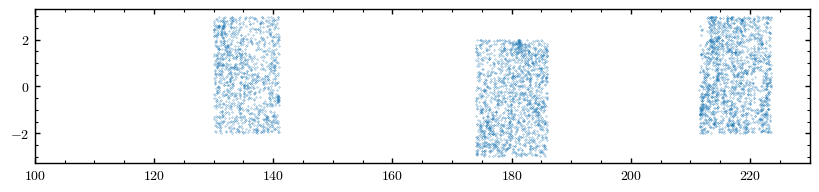

In [13]:
plt.figure(figsize = (10,2))
plt.scatter(tot_cat_slice_gama["RA"], tot_cat_slice_gama["DEC"],s=0.05)
plt.xlim([100,230])


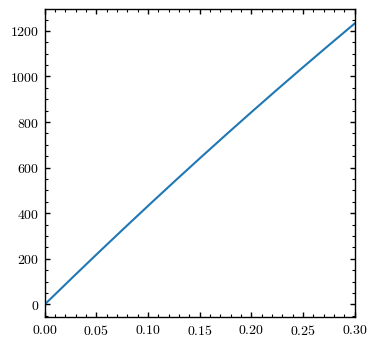

In [19]:
zmax = 0.3

zgrid = np.linspace(0.001,zmax,1000)

cmov_dist = Planck18.comoving_distance(zgrid)

from scipy.interpolate import UnivariateSpline

spl_z = UnivariateSpline( cmov_dist, zgrid, s=0.)

plt.figure(figsize = (4,4))
plt.plot(zgrid, cmov_dist)
plt.xlim([0,zmax])
plt.show()

In [34]:
from astropy.table import Table

# saga_gals = Table.read('https://sagasurvey.org/data/saga-dr3-tableC2.txt', format='ascii.mrt')
saga_gals = Table.read("/pscratch/sd/v/virajvm/catalog/saga_dr3_dwarf_cat.fits")
print(len(saga_gals))

saga_gals.rename_columns(["RAdeg", "DEdeg","z"], ["RA","DEC","Z"])

8954


In [35]:
##measure stellar mass in same way as we are measuring the other stellar masses

saga_slice_mask = (saga_gals["RA"] < 230) & (saga_gals["RA"] > 130) & (saga_gals["DEC"] < 5) & (saga_gals["DEC"] > -5) & (saga_gals["Z"] >0) & (saga_gals["Z"] < 0.3)

saga_gals_slice = saga_gals[saga_slice_mask]

print(len(saga_gals_slice))

saga_gals_slice["comov_dist"] = Planck18.comoving_distance(saga_gals_slice["Z"]).data


1500


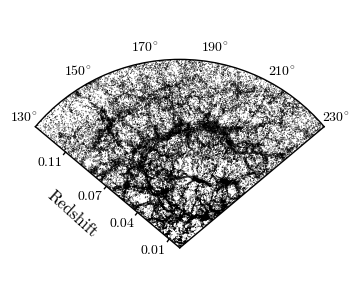

In [203]:
ra_ticks_vals = np.array([130,150, 170, 190, 210, 230])
ra_min = 130
ra_max = 230
pad_val =-15

fig, ax = plt.subplots(1,1,figsize = (3.75,3.75),subplot_kw={'projection': 'polar'})

### ALL GALAXIES IN NED-LVS
ra_radians = np.deg2rad(tot_cat_slice["RA"])
ax.scatter(ra_radians, tot_cat_slice["LUMI_DIST_MPC"], color = "k", alpha=0.6,s=0.5,
           rasterized=True, linewidths=0, edgecolors="none")

# Add labels and a colorbar
ax.set_theta_zero_location("S")  # Optional: sets 0° at the bottom (South)
ax.set_theta_direction(-1)       # Optional: clockwise direction for RA
# Set title and labels
ax.set_thetamin(ra_min)   # Min angle in degrees (start of the slice)
ax.set_thetamax(ra_max)
ax.set_rlim(0,600)

ax.set_rticks([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])

ax.set_yticklabels([r"$0.01$","0.04","0.07","0.11"])

# Add the label using ax.text()
ax.text(np.deg2rad(108),        # angle in radians
        ax.get_rmax() * 0.6,   # just outside the outermost circle
        "Redshift",
        rotation=-42,
        ha='center',
        va='center',
       fontsize = 12)

ax.grid(ls = ":", color = "lightgrey",alpha = 0.5)

rtick_vals = [44.20505558, 175.56757391, 305.02911976, 474.64670145]
tick_len = 10  # in data units (radius units), tweak to taste

for theta_deg, direction in [(ra_min, -1)]:
    theta = np.deg2rad(theta_deg)
    for r in rtick_vals:
        dtheta = direction * tick_len / r
        ax.plot([theta, theta + dtheta], [r, r],
                color='k', lw=1, clip_on=False)

ra_ticks = np.deg2rad(ra_ticks_vals)
ax.set_xticks(ra_ticks)
ax.set_xticklabels([fr'${int(r)}\!^\circ$' for r in ra_ticks_vals])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_slice_plot.pdf",dpi=300)

plt.show()


In [166]:
Planck18.comoving_distance([0.01,0.04,0.07,0.11]).value

array([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])

In [177]:
import cmasher as cmr
from matplotlib.lines import Line2D

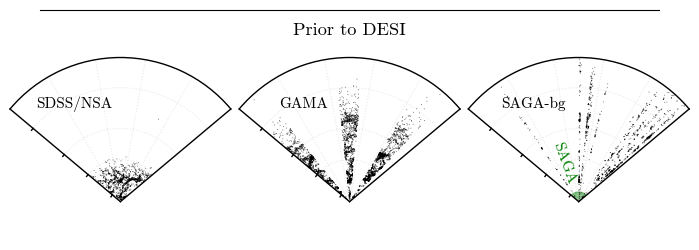

In [197]:
fig, axes = plt.subplots(1, 3, figsize=(2.5*2.75, 2.5),
                         subplot_kw={'projection': 'polar'},
                         constrained_layout=True)

fig.suptitle("Prior to DESI",y=0.93)
            # bbox=dict(boxstyle='round,pad=0.4',
            #            facecolor='white', edgecolor='k', lw=0.8))

line = Line2D([0.05, 0.95], [1.05-0.07, 1.05-0.07],
              color='k', lw=0.8,
              transform=fig.transFigure, figure=fig)
fig.add_artist(line)

rmax_val = 450
marker_size = 0.5

ra_radians = np.deg2rad(tot_cat_slice_sdss["RA"])
axes[0].scatter(ra_radians, tot_cat_slice_sdss["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")

axes[0].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "SDSS/NSA",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

######

ra_radians = np.deg2rad(tot_cat_slice_gama["RA"])

axes[1].scatter(ra_radians, tot_cat_slice_gama["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")

axes[1].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "GAMA",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

#####

ra_radians = np.deg2rad(saga_gals_slice["RA"])
axes[2].scatter(ra_radians, saga_gals_slice["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")


# Parameters
r_max_shade = 40  # Up to what radius to shade
n_points = 500     # Resolution of the fill
theta1 = np.deg2rad(ra_min)
theta2 = np.deg2rad(ra_max)
theta = np.linspace(theta1, theta2, n_points)

# Create a filled sector
r_inner = np.zeros_like(theta)
r_outer = np.full_like(theta, r_max_shade)

# Fill from center to outer radius
axes[2].fill(np.concatenate([theta, theta[::-1]]),
        np.concatenate([r_inner, r_outer[::-1]]),
        color='green', alpha=0.5, zorder=0)

axes[2].text(np.deg2rad(160),        # angle in radians
        175,   # just outside the outermost circle
        "SAGA",
        color = "green",
        alpha = 1,
        rotation=-70,
        ha='center',
        va='center')


axes[2].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "SAGA-bg",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

for axi in axes:
    axi.set_theta_zero_location("S")  # Optional: sets 0° at the bottom (South)
    axi.set_theta_direction(-1)       # Optional: clockwise direction for RA
    # Set title and labels
    # ax.set_title('Galaxy Distribution by Redshift and RA')
    axi.set_thetamin(ra_min)   # Min angle in degrees (start of the slice)
    axi.set_thetamax(ra_max)
    axi.set_rlim(0,600)

    axi.tick_params(axis='x', pad=0)  # negative moves labels closer to the plot

    axi.set_rticks([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])
    
    axi.set_yticklabels([r"","","",""])

    ra_ticks = np.deg2rad(ra_ticks_vals)
    
    axi.set_xticks(ra_ticks)
    axi.set_xticklabels([fr'' for r in ra_ticks_vals])
    
    axi.grid(ls = ":", color = "lightgrey",alpha = 0.5)
    
    rtick_vals = [44.20505558, 175.56757391, 305.02911976, 474.64670145]
    tick_len = 10  # in data units (radius units), tweak to taste
    
    for theta_deg, direction in [(ra_min, -1)]:
        theta = np.deg2rad(theta_deg)
        for r in rtick_vals:
            dtheta = direction * tick_len / r
            axi.plot([theta, theta + dtheta], [r, r],
                    color='k', lw=1, clip_on=False)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/other_slice_plot.pdf",dpi=300)
    
plt.show()



In [204]:
print(len(tot_cat))

from catalog_paper_plots import get_density_map
from healpy.newvisufunc import projview


397400


In [205]:

area = 100*10

area_mask = (tot_cat["RA"] < 230) & (tot_cat["RA"] > 130) & (tot_cat["DEC"] < 5) & (tot_cat["DEC"] > -5)

bgsb_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "BGS_BRIGHT") & area_mask ] )
bgsf_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "BGS_FAINT") & area_mask] )
lowz_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "LOWZ") & area_mask] )
elg_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "ELG") & area_mask] )

print(f"BGS Bright density = {bgsb_tgts/area:.2f}")
print(f"BGS Faint density = {bgsf_tgts/area:.2f}")
print(f"LOWZ density = {lowz_tgts/area:.2f}")
print(f"ELG density = {elg_tgts/area:.2f}")

print(len(tot_cat))

BGS Bright density = 24.15
BGS Faint density = 10.96
LOWZ density = 16.58
ELG density = 31.37
397400


In [206]:
samples = ["BGS", "LOWZ", "ELG"]
mass_bins = [(6, 7), (7, 8), (8, 9), (9, 9.25)]

for sample in samples:
    if sample == "BGS":
        sample_mask = ((tot_cat["SAMPLE"] == "BGS_BRIGHT") | (tot_cat["SAMPLE"] == "BGS_FAINT")) & area_mask
    else:
        sample_mask = (tot_cat["SAMPLE"] == sample) & area_mask
    
    total = len(tot_cat[sample_mask])
    print(f"\n{sample}: total density = {total/area:.2f}")
    
    for lo, hi in mass_bins:
        mass_mask = sample_mask & (tot_cat["LOG_MSTAR_M24"] >= lo) & (tot_cat["LOG_MSTAR_M24"] < hi)
        count = len(tot_cat[mass_mask])
        print(f"  M* [{lo}-{hi}): {count/area:.2f}  (N={count}), (NTOTAL_DESI_Y5 = {round(1.1 * 14000 * count / area, -2):.0f})")


BGS: total density = 35.11
  M* [6-7): 0.07  (N=68), (NTOTAL_DESI_Y5 = 1000)
  M* [7-8): 1.11  (N=1113), (NTOTAL_DESI_Y5 = 17100)
  M* [8-9): 20.13  (N=20132), (NTOTAL_DESI_Y5 = 310000)
  M* [9-9.25): 13.80  (N=13798), (NTOTAL_DESI_Y5 = 212500)

LOWZ: total density = 16.58
  M* [6-7): 0.04  (N=41), (NTOTAL_DESI_Y5 = 600)
  M* [7-8): 0.97  (N=970), (NTOTAL_DESI_Y5 = 14900)
  M* [8-9): 11.01  (N=11008), (NTOTAL_DESI_Y5 = 169500)
  M* [9-9.25): 4.56  (N=4560), (NTOTAL_DESI_Y5 = 70200)

ELG: total density = 31.37
  M* [6-7): 0.17  (N=172), (NTOTAL_DESI_Y5 = 2600)
  M* [7-8): 9.55  (N=9552), (NTOTAL_DESI_Y5 = 147100)
  M* [8-9): 20.77  (N=20768), (NTOTAL_DESI_Y5 = 319800)
  M* [9-9.25): 0.87  (N=869), (NTOTAL_DESI_Y5 = 13400)


In [27]:
# 900+600+5000
# 15000+12000+140000
# 211000 +117000 + 424000
# 183000 + 67000 + 64000

print(900+15000 + 211000+183000 )
print(600 + 12000 + 117000 + 67000 )
print(5000 + 140000 + 424000 + 64000) 
print(6500 + 167000 + 752000 + 314000) 


409900
196600
633000
1239500


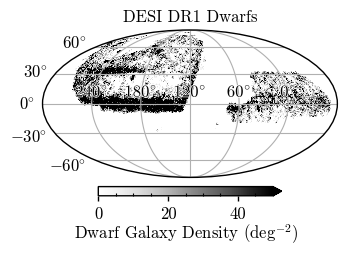

In [202]:
##let us compute the target sample specific target densities

density_map_64 = get_density_map(128, tot_cat["RA"].data, tot_cat["DEC"].data)

cmap = matplotlib.colormaps['Greys'].copy()
cmap.set_bad(color='white')

fontsize_dict = {"cbar_label":12, "cbar_tick_label":12}

ax = projview(
    density_map_64, min=0,max = 50,rot = (120, 0, 0), graticule=True, graticule_labels=True, projection_type="mollweide",
    nest=True,cmap = cmap,
    rot_graticule=False,width = 3.25,
    custom_xtick_labels=[r"$240^{\circ}$",r"$180^{\circ}$",r"$120^{\circ}$", r"$60^{\circ}$",r"$0^{\circ}$"],
    unit=r"Dwarf Galaxy Density (deg$^{-2}$)",cbar_ticks=[0,20,40],
    fontsize=fontsize_dict
)

##adding the rectangle 

# Define rectangle corners in RA/Dec
ra1, ra2 = 130 + 120, 230 + 120  # degrees
dec1, dec2 = -5, 5  # degrees

# Convert RA from [0,360] -> [-180,180] and then to radians
def ra_to_mollweide_radians(ra_deg):
    ra_wrapped = ((ra_deg + 180) % 360) - 180  # wrap into [-180, 180]
    return np.deg2rad(ra_wrapped)

# Convert Dec to radians directly
def dec_to_radians(dec_deg):
    return np.deg2rad(dec_deg)

# Get rectangle edges
ra_edges = [ra1, ra2, ra2, ra1, ra1]
dec_edges = [dec1, dec1, dec2, dec2, dec1]

x = ra_to_mollweide_radians(np.array(ra_edges))
y = dec_to_radians(np.array(dec_edges))

# Plot on the current axes (projview uses gca)
ax = plt.gca()
# ax.plot(x, y, color='r', lw=1,ls = "--",alpha=0.75)

yref = -20
shift = 12

import matplotlib.patheffects as pe

# Outline RA tick labels
for label in ax.get_xticklabels():
    label.set_color("black")
    label.set_path_effects([
        pe.Stroke(linewidth=1, foreground="white"),
        pe.Normal()
    ])


#######

ax.tick_params(
    axis="both",
    which="major",
)

ax.set_title(r"DESI DR1 Dwarfs")

ax.set_yticklabels([fr'${int(r)}\!^\circ$' for r in [-60,-30,0,30,60]])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_galaxy_density.pdf")

plt.show()


In [ ]:
18 + 8 + 13 + 41

# Make a plot of number density of dwarf galaxies as a function of redshift?

For comparison, make some stellar mass function estimate?

In [7]:
from consolidate_photometry import load_clean_dwarf_catalog

In [8]:
main_cat = load_clean_dwarf_catalog()

load_clean_dwarf_catalog
  File: /pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits
  HDU:  MAIN
  Galaxies before filter (DWARF_MASKBIT == 0): 461488
  Galaxies after  filter (DWARF_MASKBIT == 0): 431791 (29697 dropped)


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# ---- cosmology ----
cosmo = Planck18

# ---- helper: solid angle of an RA/Dec box (steradians) ----
def box_solid_angle(ra_lo, ra_hi, dec_lo, dec_hi):
    return np.deg2rad(ra_hi - ra_lo) * (np.sin(np.deg2rad(dec_hi)) - np.sin(np.deg2rad(dec_lo)))

def sr_to_sqdeg(sr):
    return sr * (180.0 / np.pi)**2

# ---- DESI / SDSS comparison footprint ----
ra_lo, ra_hi = 130.0, 230.0
dec_lo, dec_hi = -5.0, 5.0
omega_desi = box_solid_angle(ra_lo, ra_hi, dec_lo, dec_hi)
fsky_desi  = omega_desi / (4 * np.pi)
print(f"DESI/SDSS footprint: {sr_to_sqdeg(omega_desi):.1f} deg^2")

# ---- GAMA equatorial fields (GAMA-II, 60 deg^2 each) ----
gama_fields = {
    "G09": (129.0, 141.0, -2.0,  3.0),
    "G12": (174.0, 186.0, -3.0,  2.0),
    "G15": (211.5, 223.5, -2.0,  3.0),
}
omega_gama = sum(box_solid_angle(*b) for b in gama_fields.values())
fsky_gama  = omega_gama / (4 * np.pi)
print(f"GAMA footprint:      {sr_to_sqdeg(omega_gama):.1f} deg^2")

def in_gama_equatorial(ra, dec, fields=gama_fields):
    ra = np.asarray(ra); dec = np.asarray(dec)
    m = np.zeros(len(ra), dtype=bool)
    for (ra_lo, ra_hi, dec_lo, dec_hi) in fields.values():
        m |= (ra >= ra_lo) & (ra <= ra_hi) & (dec >= dec_lo) & (dec <= dec_hi)
    return m

# ---- shell volume via astropy ----
def shell_volume(z_lo, z_hi, fsky, cosmo):
    V_lo = cosmo.comoving_volume(z_lo).to(u.Mpc**3).value
    V_hi = cosmo.comoving_volume(z_hi).to(u.Mpc**3).value
    return fsky * (V_hi - V_lo)  # Mpc^3

# ---- redshift bins ----
z_edges   = np.arange(0.001, 0.15, 0.005)
z_centers = 0.5 * (z_edges[1:] + z_edges[:-1])

vol_desi = np.array([shell_volume(z_edges[i], z_edges[i+1], fsky_desi, cosmo)
                     for i in range(len(z_edges)-1)])
vol_gama = np.array([shell_volume(z_edges[i], z_edges[i+1], fsky_gama, cosmo)
                     for i in range(len(z_edges)-1)])



DESI/SDSS footprint: 998.7 deg^2
GAMA footprint:      179.9 deg^2


In [63]:
# ---- n(z) helper ----
def n_of_z(cat, z_edges, vol_bins, zcol="Z"):
    z = np.asarray(cat[zcol])
    counts, _ = np.histogram(z, bins=z_edges)
    n     = counts / vol_bins
    n_err = np.sqrt(counts) / vol_bins
    return counts, n, n_err


def n_of_z_jackknife(cat, z_edges, fsky, n_patches=20,
                     ra_col="RA", dec_col="DEC", zcol="Z",
                     ra_range=(130, 230), dec_range=(-5, 5)):
    ra  = np.asarray(cat[ra_col])
    dec = np.asarray(cat[dec_col])
    z   = np.asarray(cat[zcol])
    z_edges = np.asarray(z_edges)
    nbins = len(z_edges) - 1

    # Split footprint into equal-width RA strips
    ra_lo, ra_hi = ra_range
    edges = np.linspace(ra_lo, ra_hi, n_patches + 1)
    patch_id = np.digitize(ra, edges) - 1
    patch_id = np.clip(patch_id, 0, n_patches - 1)

    # Precompute full-sky shell volumes once
    cv = cosmo.comoving_volume(z_edges).to(u.Mpc**3).value  # shape (nbins+1,)
    shell_fullsky = np.diff(cv)                              # shape (nbins,)

    # Full-footprint volume and central n(z)
    vol_full = shell_fullsky * float(fsky)                   # shape (nbins,)
    counts, _ = np.histogram(z, bins=z_edges)
    n = counts / vol_full

    # Leave-one-out resamples (each drops 1/n_patches of the area)
    fsky_jk = float(fsky) * (n_patches - 1) / n_patches
    vol_jk  = shell_fullsky * fsky_jk

    n_samples = np.zeros((n_patches, nbins))
    for k in range(n_patches):
        keep = patch_id != k
        c_k, _ = np.histogram(z[keep], bins=z_edges)
        n_samples[k] = c_k / vol_jk

    n_mean = n_samples.mean(axis=0)
    n_err  = np.sqrt((n_patches - 1) / n_patches *
                     np.sum((n_samples - n_mean)**2, axis=0))

    return counts, n, n_err


In [64]:


# ---- DESI selection ----
comp_reg_mask = ((main_cat["RA"]  < 230) & (main_cat["RA"]  > 130) &
                 (main_cat["DEC"] >  -5) & (main_cat["DEC"] <   5))
main_cat_bgsb = main_cat[(main_cat["SAMPLE"] != "ELG") & (main_cat["SAMPLE"] != "OTHER") &
                         comp_reg_mask &
                         (main_cat["DWARF_PRIMARY"] == True)]

main_cat_bgsb_7 = main_cat_bgsb[(main_cat_bgsb["LOG_MSTAR_M24"] > 6.75) & (main_cat_bgsb["LOG_MSTAR_M24"] < 7.25)]
main_cat_bgsb_8 = main_cat_bgsb[(main_cat_bgsb["LOG_MSTAR_M24"] > 7.75) & (main_cat_bgsb["LOG_MSTAR_M24"] < 8.25)]
main_cat_bgsb_9 = main_cat_bgsb[(main_cat_bgsb["LOG_MSTAR_M24"] > 8.75) & (main_cat_bgsb["LOG_MSTAR_M24"] < 9.25)]

# ---- SDSS selection (apply the SAME footprint cut so vol_desi is correct) ----
sdss_box = ((tot_cat_slice_sdss["RA"]  < 230) & (tot_cat_slice_sdss["RA"]  > 130) &
            (tot_cat_slice_sdss["DEC"] >  -5) & (tot_cat_slice_sdss["DEC"] <   5))
sdss_in = tot_cat_slice_sdss[sdss_box]
sdss_cat_7 = sdss_in[(sdss_in["MSTAR"] > 6.75) & (sdss_in["MSTAR"] < 7.25)]
sdss_cat_8 = sdss_in[(sdss_in["MSTAR"] > 7.75) & (sdss_in["MSTAR"] < 8.25)]
sdss_cat_9 = sdss_in[(sdss_in["MSTAR"] > 8.75) & (sdss_in["MSTAR"] < 9.25)]

# ---- GAMA selection (apply GAMA equatorial mask) ----
gama_in_mask = in_gama_equatorial(tot_cat_slice_gama["RA"], tot_cat_slice_gama["DEC"])
gama_in = tot_cat_slice_gama[gama_in_mask]
gama_7 = gama_in[(gama_in["MSTAR"] > 6.75) & (gama_in["MSTAR"] < 7.25)]
gama_8 = gama_in[(gama_in["MSTAR"] > 7.75) & (gama_in["MSTAR"] < 8.25)]
gama_9 = gama_in[(gama_in["MSTAR"] > 8.75) & (gama_in["MSTAR"] < 9.25)]

# ---- sample dicts (one entry per mass bin per survey) ----
mass_labels = [r"$\log M_\star \sim 7$", r"$\log M_\star \sim 8$", r"$\log M_\star \sim 9$"]
colors      = ["C1", "C2", "C3"]

desi_samples = dict(zip(mass_labels, zip([main_cat_bgsb_7, main_cat_bgsb_8, main_cat_bgsb_9], colors)))
sdss_samples = dict(zip(mass_labels, zip([sdss_cat_7,      sdss_cat_8,      sdss_cat_9     ], colors)))
gama_samples = dict(zip(mass_labels, zip([gama_7,          gama_8,          gama_9         ], colors)))



In [65]:
# ---- DESI selection ----
comp_reg_mask = ((main_cat["RA"]  < 230) & (main_cat["RA"]  > 130) &
                 (main_cat["DEC"] >  -5) & (main_cat["DEC"] <   5))
main_cat_elg = main_cat[(main_cat["SAMPLE"] == "ELG") & (main_cat["MAG_TYPE"] == "TRACTOR_OG") &
                         comp_reg_mask &
                         (main_cat["DWARF_PRIMARY"] == True)]

main_cat_elg_7 = main_cat_elg[(main_cat_elg["LOG_MSTAR_M24"] > 6.75) & (main_cat_elg["LOG_MSTAR_M24"] < 7.25)]
main_cat_elg_8 = main_cat_elg[(main_cat_elg["LOG_MSTAR_M24"] > 7.75) & (main_cat_elg["LOG_MSTAR_M24"] < 8.25)]
main_cat_elg_9 = main_cat_elg[(main_cat_elg["LOG_MSTAR_M24"] > 8.75) & (main_cat_elg["LOG_MSTAR_M24"] < 9.25)]

desi_elg_samples = dict(zip(mass_labels, zip([main_cat_elg_7, main_cat_elg_8, main_cat_elg_9], colors)))


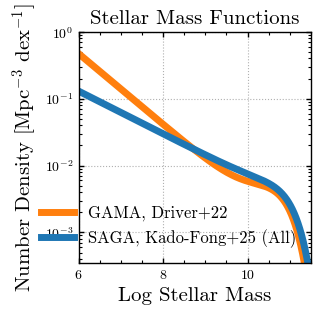

In [66]:
## now let us integrate the SMF and do some magnitude limited comparisons.. 
from astropy.cosmology import Planck18
from astropy import units as u
from scipy.integrate import quad

##all these units appear to contain hinverses in them. So the final 

#Driver 2022 Table 7 numbers
Mc = 10**10.745
alpha_1 = -0.466
phi_star_1 = 10**(-2.437 + 0*0.0807)
alpha_2 = -1.530
phi_star_2 = 10**(-3.201 + 0*0.0807)

smf_field = { "Mc":10**10.63, "phi_star_2": 0.89/1e3, "phi_star_1": 2.24/1e3, "alpha_2": -1.36, "alpha_1": -0.38 }

smf_all = { "Mc":10**10.83, "phi_star_2": 1.61/1e3, "phi_star_1": 2.77/1e3, "alpha_2": -1.32, "alpha_1": -0.36 }


def schecter_mf(Mstar,alpha, phi_star,Mc):
    '''
    Mstar here is not in log units. Furthermore, we want the density to be in log quantities (dM where M is log). The extra factors come from derivative of dlogM
    '''
    return np.log(10) * phi_star * (10**(np.log10(Mstar/Mc)*(alpha+1) ) ) * np.exp(- 10**(np.log10(Mstar/Mc)) )


def GSMF(LogMstar,alpha_1=alpha_1, phi_star_1=phi_star_1, alpha_2 = alpha_2, phi_star_2 = phi_star_2, Mc = Mc):
    Mstar = 10**LogMstar
    return schecter_mf(Mstar,alpha_1, phi_star_1,Mc=Mc) + schecter_mf(Mstar,alpha_2, phi_star_2,Mc)


def EKF_SMF(LogMstar,smf_field=smf_all):
    Mstar = 10**LogMstar
    alpha_1 = smf_field["alpha_1"]
    phi_star_1=smf_field["phi_star_1"]
    alpha_2=smf_field["alpha_2"]
    phi_star_2=smf_field["phi_star_2"]
    Mc=smf_field["Mc"]

    return schecter_mf(Mstar,alpha_1, phi_star_1,Mc=Mc) + schecter_mf(Mstar,alpha_2, phi_star_2,Mc=Mc)

# def SMF_D(LogMstar):
#     Mstar = 10**LogMstar
#     return  schecter_mf(Mstar,tab9_SF_vals["alpha"], 10**tab9_SF_vals["phi_star"], 10**tab9_SF_vals["Mc"] )
    
#lifting data from Figure 12 for comparison
d22_xvals = [6.145194696789444,6.912615603047123,  7.488175431890253, 7.988399714478514, 8.468052408014884, 8.995658669204635, 9.550787329398961,10.051198839191334,10.524204966981703,10.948953282912008,11.202107866272968,11.42741240302216,11.563503177011619,11.67902236194919,11.746751803036982]
d22_yvals = 10**np.array([-0.3391542791167552, -0.7614101328923089, -1.0823682681093558, -1.3354955475030512, -1.5887398438993179, -1.8758410597059743, -2.0945263346764276, -2.211133777737904, -2.3108322639279475, -2.5985185647474567, -3.006634864045745, -3.7220768177616197, -4.489220783779882, -5.256481766800714, -5.870430973620467])


ekf_all_mstar = [
    6.652356130654582,
    7.080729234879639,
    7.660030908662284,
    8.064200958692407,
    8.677554548550173,
    9.037823820624984,
    9.232548393011498,
    9.490557141734552,
    9.821594153547949,
    10.181968200749141,
    10.493517039054929,
    10.829164156429265,
    11.1354742384158,
    11.271158027084368
]

ekf_all_phi = [
    -1.0862823165780444,
    -1.2391230321921576,
    -1.4357859444167955,
    -1.5239804070513658,
    -1.7423317704376977,
    -1.851795583728423,
    -1.917358619063834,
    -2.0047672682505175,
    -2.114073918851665,
    -2.180527542761348,
    -2.289729418236111,
    -2.5065877360714572,
    -2.766299080598266,
    -3.068103832150248
]

## plotting the GSMF
mstar_vals = np.linspace(6,11.5,500)
gama_smf_vals = GSMF(mstar_vals)

all_smf_vals = EKF_SMF(mstar_vals,smf_all)

#plotting to see if I can match the GSMF from figure. They agree!
plt.figure(figsize = (3,3))
plt.plot(mstar_vals, gama_smf_vals,label = "GAMA, Driver+22",lw = 5,color = "tab:orange")

plt.plot(mstar_vals, all_smf_vals,lw = 5, label = "SAGA, Kado-Fong+25 (All)")

plt.title("Stellar Mass Functions",fontsize = 15)
plt.yscale("log")
plt.ylabel("Number Density [Mpc$^{-3}$ dex$^{-1}$]",fontsize = 15)
plt.xlabel("Log Stellar Mass",fontsize = 15)
plt.ylim([3.5e-4, 1])
plt.xlim([6, 11.5])
plt.legend(frameon=False,fontsize = 12)
plt.grid(ls = ":")
plt.show()


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from scipy.optimize import brentq

# Redshift grid: match the data n(z) plot exactly
z_edges   = np.arange(0.001, 0.15, 0.005)
z_centers = 0.5 * (z_edges[1:] + z_edges[:-1])
n_zbins   = len(z_centers)

# Stellar-mass bins (width 0.5 dex, centers at 7, 8, 9)
mass_bins = {
    r"$\log M_\star \sim 7$": (6.75, 7.25),
    r"$\log M_\star \sim 8$": (7.75, 8.25),
    r"$\log M_\star \sim 9$": (8.75, 9.25),
}

# r-band magnitude limits
rmag_limits = {
    "Volume-limited":             None,
    "SDSS (r<17.7)":              17.7,
    "DESI BGS Bright (r<19.5)":   19.5,
    "DESI BGS+LOWZ (r<21.15)":    21.15,
}


def get_mstar_gr(log_mstar):
    """Mean g-r color as a function of stellar mass (capped at 0.8)."""
    ave_gr = 0.09 * log_mstar - 0.3857
    return np.minimum(0.8, ave_gr)

In [76]:
def get_logM_min_observable(zred, rmag_limit, logM_floor=3.0, logM_ceil=12.0):
    """
    Find the minimum observable log M* at redshift `zred` for an r-band
    magnitude limit `rmag_limit`, using a mass-dependent g-r color.

    Stellar mass relation (Mg-based, converted to r):
        logM = 1.986 + 1.315 * gr - 0.365 * M_g
             = 1.986 + 0.950 * gr - 0.365 * M_r       (since M_g = M_r + gr)

    Color relation:
        gr = get_mstar_gr(logM)   (mass-dependent, capped at 0.8)

    These are coupled. We solve self-consistently by finding the root of
        f(logM) = logM - [1.986 + 0.950 * gr(logM) - 0.365 * M_r] = 0
    """
    # Apparent r -> absolute M_r at this redshift
    lumi_dist = Planck18.luminosity_distance(zred).value      # Mpc
    mu = 5.0 * np.log10(lumi_dist * 1e6) - 5.0
    M_r = rmag_limit - mu

    # Closed-form logM that the relation would give for a *specified* gr
    def logM_from_gr(gr):
        return 1.986 + 0.950 * gr - 0.365 * M_r

    # f(logM) = predicted logM (using gr=gr(logM)) minus logM itself.
    # Root of f = self-consistent solution.
    def f(logM):
        return logM_from_gr(get_mstar_gr(logM)) - logM

    # Check that a root exists in the bracket. If not, the function is
    # monotonically positive or negative -> handle edge cases.
    f_lo, f_hi = f(logM_floor), f(logM_ceil)
    if f_lo * f_hi > 0:
        # No sign change: either the limit is so deep that even logM_floor
        # is observable (f_lo < 0 everywhere) or so shallow that nothing is
        # (f_hi > 0 everywhere).
        return logM_floor if f_lo < 0 else logM_ceil

    return brentq(f, logM_floor, logM_ceil)

In [77]:
# At z=0.05 with r<19.5, what's the minimum observable mass?
z_test = 0.05
for rlim in [17.7, 19.5, 21.15]:
    logM_min = get_logM_min_observable(z_test, rlim)
    print(f"r<{rlim}: logM_min = {logM_min:.2f}, "
          f"gr at that mass = {get_mstar_gr(logM_min):.2f}")

r<17.7: logM_min = 9.40, gr at that mass = 0.46
r<19.5: logM_min = 8.68, gr at that mass = 0.40
r<21.15: logM_min = 8.02, gr at that mass = 0.34


In [78]:
def predict_nz_in_mass_bin(smf_func, z_edges, logM_lo, logM_hi,
                           rmag_limit=None):
    """
    Predict n(z) [Mpc^-3] in stellar-mass bin [logM_lo, logM_hi] under an
    optional r-band magnitude limit. Uses the self-consistent
    color-mass relation to determine the observable mass floor at each z.
    """
    nz = np.zeros(len(z_edges) - 1)
    for i in range(len(z_edges) - 1):
        z_mid = 0.5 * (z_edges[i] + z_edges[i+1])

        if rmag_limit is None:
            lo_eff = logM_lo
        else:
            logM_min_obs = get_logM_min_observable(z_mid, rmag_limit)
            lo_eff = max(logM_lo, logM_min_obs)

        if lo_eff >= logM_hi:
            nz[i] = 0.0
            continue

        # Integrate SMF (dn/dlogM) over the observable mass range
        nz[i], _ = quad(smf_func, lo_eff, logM_hi)
    return nz

In [79]:
smfs = {
    "GAMA (Driver+22)":     GSMF,
    "EKF+25 (All)":         lambda lm: EKF_SMF(lm, smf_all),
}

# results[smf_name][rmag_label][mass_label] -> array of n(z)
results = {}
for smf_name, smf_fn in smfs.items():
    results[smf_name] = {}
    for rmag_label, rmag_lim in rmag_limits.items():
        results[smf_name][rmag_label] = {}
        for mass_label, (lo, hi) in mass_bins.items():
            results[smf_name][rmag_label][mass_label] = predict_nz_in_mass_bin(
                smf_fn, z_edges, lo, hi, rmag_limit=rmag_lim
            )

# Quick check at z=0.02
print("n(z=0.02) [Mpc^-3], GAMA SMF:")
iz = np.argmin(np.abs(z_centers - 0.01))
for rmag_label in rmag_limits:
    row = " | ".join(f"{m}: {results['GAMA (Driver+22)'][rmag_label][m][iz]:.2e}"
                     for m in mass_bins)
    print(f"  {rmag_label:30s} | {row}")

n(z=0.02) [Mpc^-3], GAMA SMF:
  Volume-limited                 | $\log M_\star \sim 7$: 7.11e-02 | $\log M_\star \sim 8$: 2.11e-02 | $\log M_\star \sim 9$: 6.57e-03
  SDSS (r<17.7)                  | $\log M_\star \sim 7$: 0.00e+00 | $\log M_\star \sim 8$: 1.65e-02 | $\log M_\star \sim 9$: 6.57e-03
  DESI BGS Bright (r<19.5)       | $\log M_\star \sim 7$: 1.49e-02 | $\log M_\star \sim 8$: 2.11e-02 | $\log M_\star \sim 9$: 6.57e-03
  DESI BGS+LOWZ (r<21.15)        | $\log M_\star \sim 7$: 7.11e-02 | $\log M_\star \sim 8$: 2.11e-02 | $\log M_\star \sim 9$: 6.57e-03


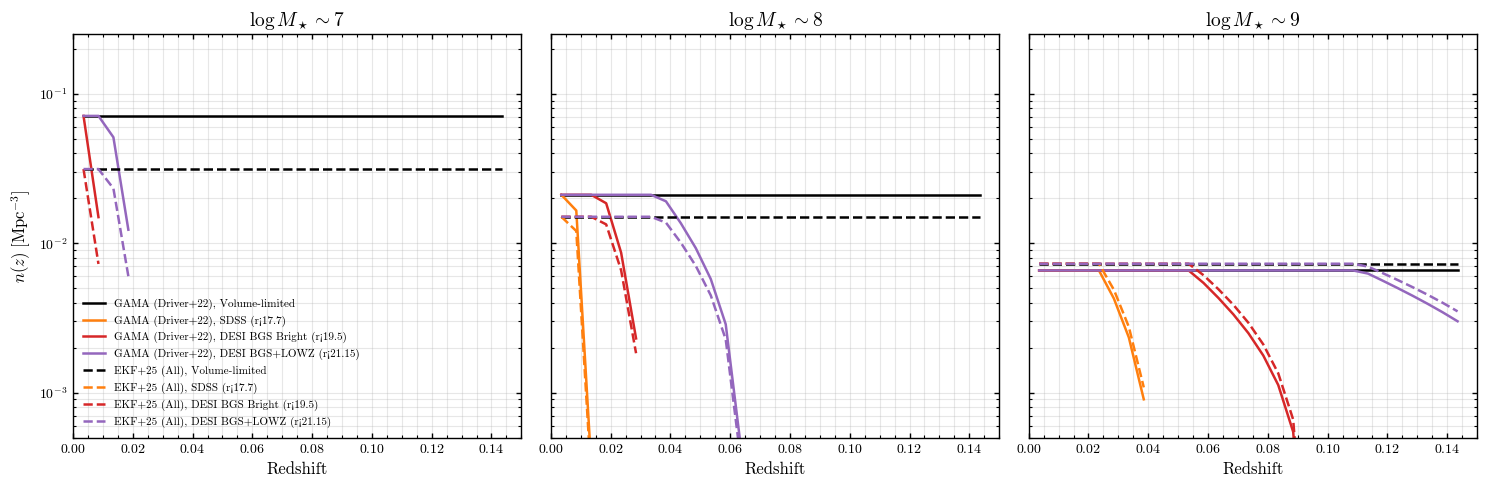

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

rmag_colors = {
    "Volume-limited":             "k",
    "SDSS (r<17.7)":              "tab:orange",
    "DESI BGS Bright (r<19.5)":   "tab:red",
    "DESI BGS+LOWZ (r<21.15)":    "tab:purple",
}
smf_ls = {
    "GAMA (Driver+22)": "-",
    "EKF+25 (All)":     "--",
}

for i, (mass_label, (lo, hi)) in enumerate(mass_bins.items()):
    ax = axes[i]
    for smf_name, ls in smf_ls.items():
        for rmag_label, color in rmag_colors.items():
            nz = results[smf_name][rmag_label][mass_label]
            m = nz > 0
            if not m.any():
                continue
            label = f"{smf_name}, {rmag_label}" if i == 0 else None
            ax.plot(z_centers[m], nz[m], ls=ls, color=color, lw=1.8, label=label)

    ax.set_yscale("log")
    ax.set_xlim(0, 0.15)
    ax.set_ylim(5e-4, 2.5e-1)
    ax.set_xlabel("Redshift")
    ax.set_title(mass_label, fontsize=14)
    ax.grid(alpha=0.3, which="both")

axes[0].set_ylabel(r"$n(z)\ [\mathrm{Mpc}^{-3}]$")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

In [84]:
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

LOGM_SAMPLE_MIN = 6.0
LOGM_SAMPLE_MAX = 12.0
GR_SCATTER      = 0.1

def build_inverse_cdf(smf_func, logM_lo=LOGM_SAMPLE_MIN, logM_hi=LOGM_SAMPLE_MAX,
                      n_grid=1000):
    grid = np.linspace(logM_lo, logM_hi, n_grid)
    cdf = np.array([quad(smf_func, logM_lo, m)[0] for m in grid])
    norm = cdf[-1]
    cdf /= norm
    return UnivariateSpline(cdf, grid, s=0, k=3), norm

gama_inv_cdf, gama_density = build_inverse_cdf(GSMF)
ekf_smf_fn = lambda lm: EKF_SMF(lm, smf_all)
ekf_inv_cdf, ekf_density   = build_inverse_cdf(ekf_smf_fn)

def Mr_from_logM_gr(logM, gr):
    """Inverse of  logM = 1.986 + 0.950*gr - 0.365*M_r"""
    return (1.986 + 0.950 * gr - logM) / 0.365

In [86]:
def build_intrinsic_catalog(inv_cdf, n_samples=1_000_000, gr_scatter=GR_SCATTER,
                            seed=42):
    """
    Sample (logM, gr, M_r) from the SMF + color relation.
    No redshift assigned -- we apply distance modulus at evaluation time.
    """
    rng = np.random.default_rng(seed)
    u_rnd = rng.uniform(0, 1, size=n_samples)
    logM  = inv_cdf(u_rnd)
    gr    = get_mstar_gr(logM) + rng.normal(0.0, gr_scatter, size=n_samples)
    M_r   = Mr_from_logM_gr(logM, gr)

    #only include objects with Mstar 

    return {"logM": logM, "gr": gr, "M_r": M_r}

mock_gama = build_intrinsic_catalog(gama_inv_cdf)
mock_ekf  = build_intrinsic_catalog(ekf_inv_cdf)

In [87]:
def nz_from_intrinsic(cat, mean_density, z_centers, logM_lo, logM_hi,
                      rmag_limit=None):
    """
    n(z) [Mpc^-3] from an intrinsic mock catalog.

    Logic: the intrinsic catalog represents the population in some fixed
    comoving volume. The fraction of galaxies in [logM_lo, logM_hi] that
    are observable at redshift z (m_r < rmag_limit) gives the *fraction* of
    the SMF visible. Multiply by the SMF density in that bin to get n(z).
    """
    in_mass_bin = (cat["logM"] >= logM_lo) & (cat["logM"] < logM_hi)
    N_in_bin = in_mass_bin.sum()
    if N_in_bin == 0:
        return np.zeros(len(z_centers))

    # Density in this mass bin (Mpc^-3) -- fraction of total times mean_density
    density_in_bin = mean_density * N_in_bin / len(cat["logM"])

    if rmag_limit is None:
        # No cut: density is z-independent
        return np.full(len(z_centers), density_in_bin)

    M_r_bin = cat["M_r"][in_mass_bin]
    nz = np.empty(len(z_centers))
    for i, z in enumerate(z_centers):
        mu = 5.0 * np.log10(Planck18.luminosity_distance(z).value * 1e6) - 5.0
        frac_visible = (M_r_bin + mu < rmag_limit).mean()
        nz[i] = density_in_bin * frac_visible
    return nz

# Compute everything
mock_results = {}
mocks = {"GAMA (Driver+22)": (mock_gama, gama_density),
         "EKF+25 (All)":     (mock_ekf,  ekf_density)}

for smf_name, (cat, density) in mocks.items():
    mock_results[smf_name] = {}
    for rmag_label, rmag_lim in rmag_limits.items():
        mock_results[smf_name][rmag_label] = {}
        for mass_label, (lo, hi) in mass_bins.items():
            mock_results[smf_name][rmag_label][mass_label] = nz_from_intrinsic(
                cat, density, z_centers, lo, hi, rmag_limit=rmag_lim
            )

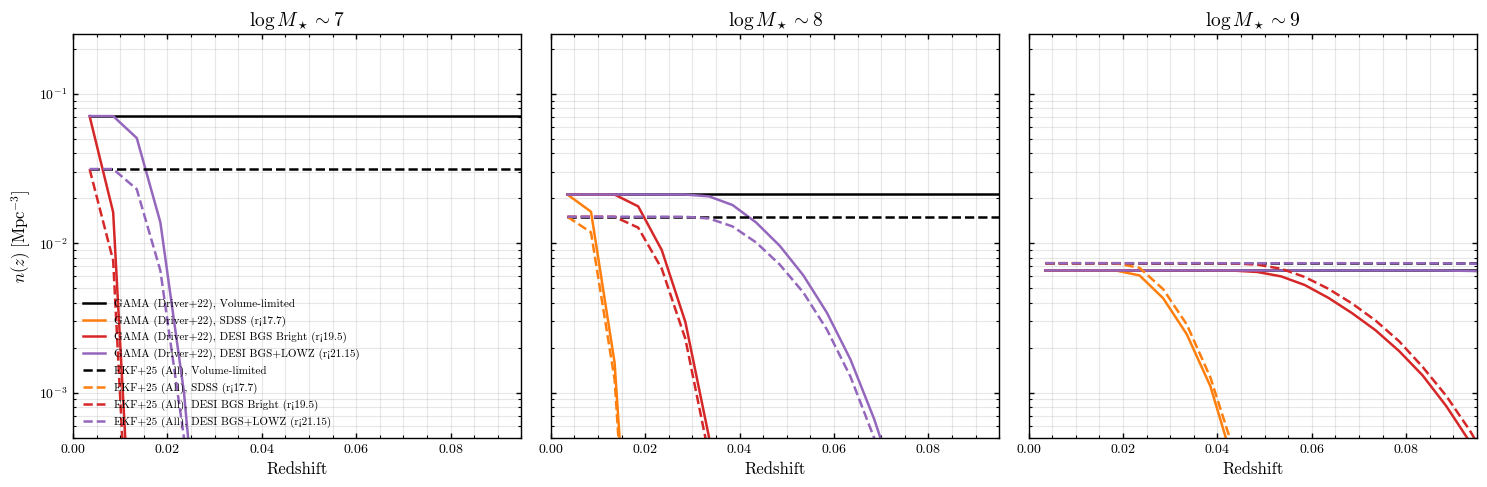

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

rmag_colors = {
    "Volume-limited":             "k",
    "SDSS (r<17.7)":              "tab:orange",
    "DESI BGS Bright (r<19.5)":   "tab:red",
    "DESI BGS+LOWZ (r<21.15)":    "tab:purple",
}
smf_ls = {"GAMA (Driver+22)": "-", "EKF+25 (All)": "--"}

for i, (mass_label, _) in enumerate(mass_bins.items()):
    ax = axes[i]
    for smf_name, ls in smf_ls.items():
        for rmag_label, color in rmag_colors.items():
            nz = mock_results[smf_name][rmag_label][mass_label]
            m = nz > 0
            if not m.any():
                continue
            label = f"{smf_name}, {rmag_label}" if i == 0 else None
            ax.plot(z_centers[m], nz[m], ls=ls, color=color, lw=1.8, label=label)

    ax.set_yscale("log")
    ax.set_xlim(0, 0.095)
    ax.set_ylim(5e-4, 2.5e-1)
    ax.set_xlabel("Redshift")
    ax.set_title(mass_label, fontsize=14)
    ax.grid(alpha=0.3, which="both")

axes[0].set_ylabel(r"$n(z)\ [\mathrm{Mpc}^{-3}]$")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

In [89]:
rmag_ls = {
    "Volume-limited":             "k",
    "SDSS (r<17.7)":              "dotted",
    "DESI BGS Bright (r<19.5)":   "-.",
    "DESI BGS+LOWZ (r<21.15)":    "--",
}

rmag_labels = {
    "Volume-limited":             None,
    "SDSS (r<17.7)":              r"$r < 17.7$",
    "DESI BGS Bright (r<19.5)":    r"$r < 19.5$",
    "DESI BGS+LOWZ (r<21.15)":     r"$r < 21.15$",
}


In [99]:
## maybe best to pick erin's smf's here??

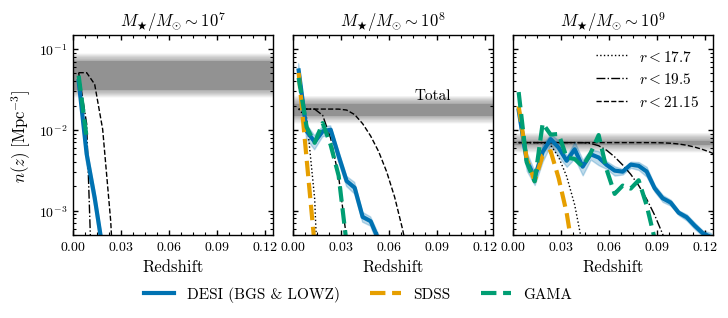

In [110]:
fig, ax = make_subplots(ncol=3, nrow=1, plot_size=2,return_fig=True,
                       col_spacing=[MARGIN_LABEL, MARGIN_SHARED+0.1, MARGIN_SHARED+0.1, MARGIN_PAD],
                       row_spacing=[MARGIN_LABEL, MARGIN_PAD])


for i, (mass_label, _) in enumerate(mass_bins.items()):
    for rmag_label, ls in rmag_ls.items():            
        nz_ekf = mock_results['EKF+25 (All)'][rmag_label][mass_label]
        nz_gama = mock_results['GAMA (Driver+22)'][rmag_label][mass_label]

        if i == 2:
            leg_label = rmag_labels[rmag_label]
        else:
            leg_label = None
            
        if rmag_label == "Volume-limited":
            x = np.concatenate([[0], z_centers])
            y1 = np.concatenate([[nz_ekf[0]], nz_ekf])
            y2 = np.concatenate([[nz_gama[0]], nz_gama])
        
            # Work in log space so the fuzzy "slope" is identical across panels
            # (constant dex offset rather than constant linear offset)
            log_hi = np.log10(np.maximum(y1, y2))
            log_lo = np.log10(np.minimum(y1, y2))
        
            n_layers = 15
            spread_dex = 0.1   # total fuzz extent in dex (tweak to taste: 0.05–0.15)
            alpha_each = 0.025   # per-layer alpha
        
            for j in range(n_layers):
                frac = (j + 1) / n_layers
                offset = spread_dex * frac
                y_hi = 10 ** (log_hi + offset)
                y_lo = 10 ** (log_lo - offset)
                ax[i].fill_between(
                    x, y1=y_hi, y2=y_lo,
                    facecolor="k", edgecolor="none",
                    alpha=alpha_each,
                    label=leg_label if j == 0 else None,
                )

            # Solid core band
            ax[i].fill_between(
                x, y1=10**log_hi, y2=10**log_lo,
                facecolor="k", edgecolor="none", alpha=0.15,
            )
        # if rmag_label == "Volume-limited":        
        #     ax[i].fill_between(np.concatenate([[0],z_centers]), y1 = np.concatenate([[nz_ekf[0]] , nz_ekf]), 
        #                         y2 = np.concatenate([[nz_gama[0]] , nz_gama]), facecolor="k", edgecolor="none",alpha=0.25, 
        #                        label = leg_label )
        else:

            nz_ave = 0.5*(nz_ekf + nz_gama)
        
            m = nz_ave > 0
            if not m.any():
                continue
                
            ax[i].plot(z_centers[m], nz_ave[m], ls=ls, color='k', lw=1, label = leg_label)

ax[2].legend(frameon=False,loc="upper right",ncol=1)

for i, label in enumerate(mass_labels):
    # DESI
    cat, color = desi_samples[label]
    # counts, n, n_err = n_of_z(cat, z_edges, vol_desi)
    counts, n, n_err = n_of_z_jackknife(cat, z_edges, fsky_desi)

    m = counts > 0
    ax[i].plot(z_centers[m], n[m], ls="-",
                   color="#0072B2", label=fr"DESI (BGS & LOWZ)", lw = 3)

    ax[i].fill_between(z_centers[m], y1=n[m] + n_err[m], y2=n[m] - n_err[m],  ls="-",
                   color="#0072B2", alpha=0.25)


    ## DESI ELG
    #THE DESI ELG number density is much lower than 1e-3, so not shwon here
    # cat, color = desi_elg_samples[label]
    
    # counts, n, n_err = n_of_z_jackknife(cat, z_edges, fsky_desi)

    # ax[i].plot(z_centers[m], n[m], ls="-",
    #                color="cyan", label=fr"DESI (ELG)", lw = 3)
    
    # SDSS
    cat, color = sdss_samples[label]
    counts, n, n_err = n_of_z_jackknife(cat, z_edges, fsky_desi) # same footprint as DESI
    
    m = counts > 0
    ax[i].plot(z_centers[m], n[m], ls="--", color="#E69F00", label=f"SDSS", lw = 3)

    # GAMA
    cat, color = gama_samples[label]
    counts, n, n_err = n_of_z(cat, z_edges, vol_gama)   # GAMA footprint
    m = counts > 0
    ax[i].plot(z_centers[m], n[m], ls = "--", color="#009E73", label=f"GAMA", lw = 3)

        # ax[i].errorbar(z_centers[m], n[m], yerr=n_err[m], fmt="^", ls=":",
                   # color="#009E73", label=f"GAMA", capsize=3, lw=1.5, ms=6, mfc="white")

    ax[i].set_yscale("log")
    ax[0].set_ylabel(r"$n(z)\ [\mathrm {Mpc}^{-3}]$")
    ax[i].set_ylim(5e-4, 1.5e-1)
    ax[i].set_xlim([0,0.125])
    
    # ax[0].legend(frameon=False, loc="upper right",ncol=2)
    
    ax[1].set_yticklabels([])
    ax[2].set_yticklabels([])
    
    ax[i].set_xlabel("Redshift")

    ax[i].set_xticks([0,0.03,0.06,0.09,0.12])

# ax[0].set_title(r"$10^{6.75} < M_{\bigstar} / M_{\odot} < 10^{7.25}$")
# ax[1].set_title(r"$10^{7.75} < M_{\bigstar} / M_{\odot} < 10^{8.25}$")
# ax[2].set_title(r"$10^{8.75} < M_{\bigstar} / M_{\odot} < 10^{9.25}$")

ax[0].set_title(r"$M_{\bigstar} / M_{\odot} \sim 10^{7}$")
ax[1].set_title(r"$M_{\bigstar} / M_{\odot} \sim 10^{8}$")
ax[2].set_title(r"$M_{\bigstar} / M_{\odot} \sim 10^{9}$")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, 0.03),   # tweak the -0.05 to move it up/down
           ncol=3,
           frameon=False)

ax[1].text(0.7,0.7,"Total",color="k",transform=ax[1].transAxes,ha="center",va="center")

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarf_nz.pdf")

plt.show()

In [111]:
## make a rough plot as well!